In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
df = pd.read_csv("amazon_sales_dataset.csv")
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


### Data clearning

In [3]:
print("Các Feature null trong df:\n",df.isnull().sum())

print("\nCác Feature trung nhau trong df:", df.duplicated().sum())

Các Feature null trong df:
 order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

Các Feature trung nhau trong df: 0


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])

print(df.dtypes)

order_id                     int64
order_date          datetime64[ns]
product_id                   int64
product_category            object
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region             object
payment_method              object
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
dtype: object


### EDA

In [5]:
cols = ['price', 'quantity_sold', 'rating', 'review_count', 'discounted_price', 'total_revenue']
summary_stats = df.groupby('product_category')[cols].agg(['mean', 'min', 'max'])

display(summary_stats)

price               quantity_sold            rating  \
                        mean   min     max          mean min max      mean   
product_category                                                             
Beauty            252.405289  5.30  499.93      3.003190   1   5  2.985186   
Books             252.682468  5.01  499.96      3.010088   1   5  3.020259   
Electronics       251.893404  5.04  499.99      2.992548   1   5  2.991298   
Fashion           252.347879  5.44  499.99      2.999283   1   5  2.987782   
Home & Kitchen    253.812631  5.03  499.89      2.996246   1   5  2.996706   
Sports            251.910161  5.02  499.91      2.994918   1   5  2.996891   

                           review_count          discounted_price        \
                  min  max         mean min  max             mean   min   
product_category                                                          
Beauty            1.0  5.0   247.580862   0  499       218.682477  3.93   
Books             1.0  5.0   247.572115   0  499       218.736729  3.65   
Electronics       1.0  5.0   248.249760   0  499       218.835779  3.53   
Fashion           1.0  5.0   250.153736   0  499       218.643613  4.28   
Home & Kitchen    1.0  5.0   251.440058   0  499       220.472089  4.02   
Sports            1.0  5.0   251.033636   0  499       217.959391  3.60   

                         total_revenue                 
                     max          mean   min      max  
product_category                                       
Beauty            499.77    655.714704  5.16  2498.85  
Books             499.89    658.684164  4.23  2492.50  
Electronics       498.67    657.523321  4.82  2492.30  
Fashion           499.50    655.125325  5.01  2483.20  
Home & Kitchen    499.65    662.767323  4.79  2493.80  
Sports            499.91    654.233009  3.84  2499.55

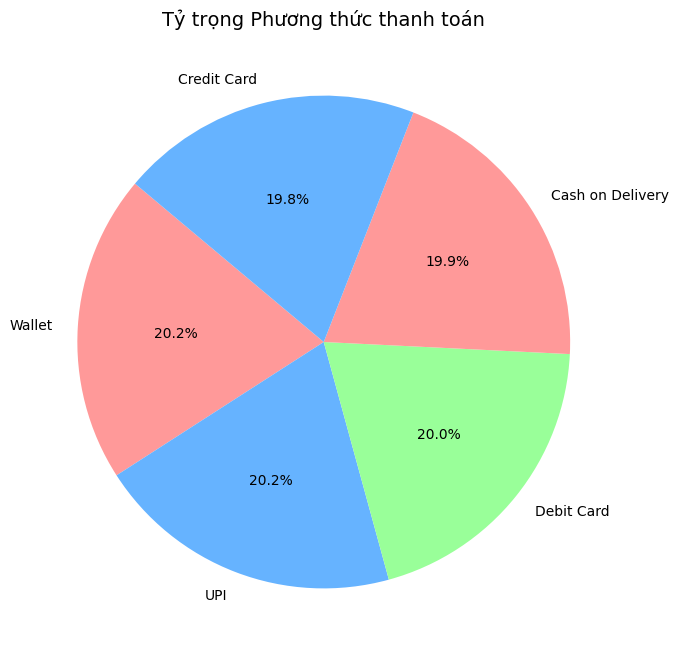

In [6]:
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Tỷ trọng Phương thức thanh toán', fontsize=14)
plt.show()

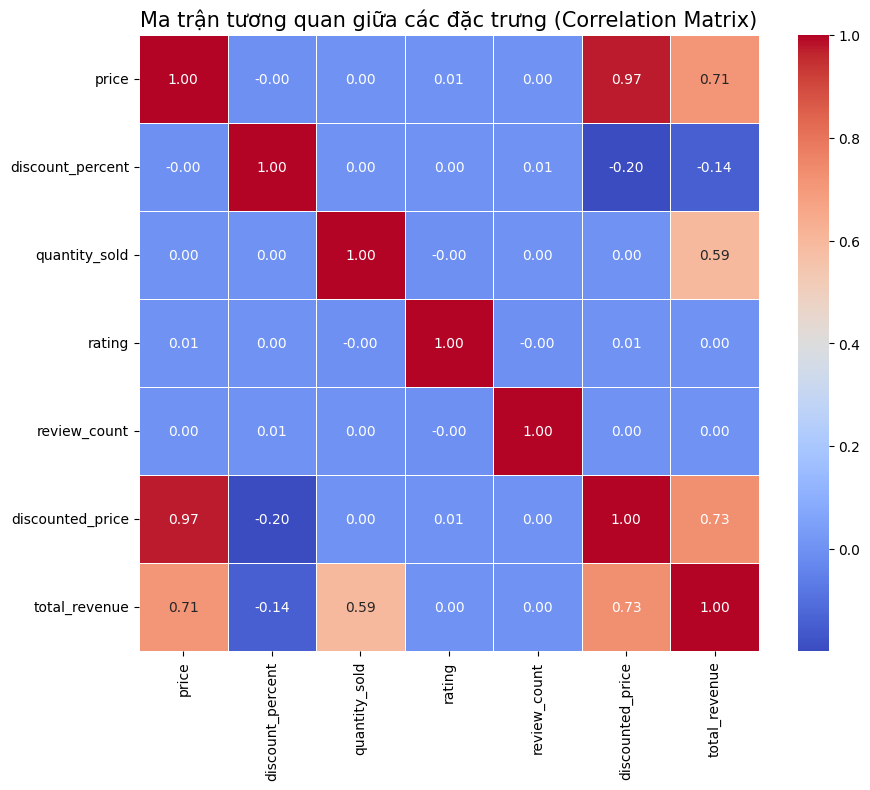

In [7]:
numeric_cols = ['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count', 'discounted_price', 'total_revenue']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths
            =0.5)

plt.title('Ma trận tương quan giữa các đặc trưng (Correlation Matrix)', fontsize=15)
plt.show()

### Feature Enginerring

In [8]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [9]:
df["year"]=df["order_date"].dt.year
df["month"]=df["order_date"].dt.month
df["day"]=df["order_date"].dt.day

In [10]:
df = df.drop(["order_id","order_date","product_id"],axis=1)

### Data Processing

In [12]:
cols = ["product_category", "customer_region", "payment_method"]

enc = OneHotEncoder(sparse_output=False)

X_encoded = enc.fit_transform(df[cols])

encoded_cols = enc.get_feature_names_out(cols)

df_encoded = pd.DataFrame(X_encoded, columns=encoded_cols, index=df.index)

df = pd.concat([df.drop(columns=cols), df_encoded], axis=1)

In [ ]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        # Tính trung bình và độ lệch chuẩn theo từng cột (axis=0)
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        # Tránh lỗi chia cho 0 nếu cột đó tất cả giá trị giống nhau
        self.std_[self.std_ == 0] = 1e-9

    def transform(self, X):
        # Áp dụng công thức: (X - mean) / std
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [ ]:
X = df.drop(["total_revenue",'discounted_price'],axis=1)
y = df['total_revenue']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tổng số mẫu: {len(df)}")
print(f"Số mẫu tập Train: {len(X_train)} (~80%)")
print(f"Số mẫu tập Test:  {len(X_test)} (~20%)")


print("Kích thước ma trận Train:", X_train.shape)
print("Kích thước ma trận Test:", X_test.shape)

In [ ]:
scaler = MyStandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Training model

In [ ]:
def compute_mse(y, y_pred):
    return np.mean((y-y_pred) ** 2)

def compute_mae(y, y_pred):
    return np.mean(np.abs(y-y_pred))

def compute_rmse(y, y_pred):
    return np.sqrt(compute_mse(y, y_pred))

def compute_r2(y, y_pred):
    ss_res = np.mean((y-y_pred) ** 2)
    ss_tot = np.mean((y - np.mean(y)) ** 2)

    return 1 - (ss_res / ss_tot)

def compute_mape(y, y_pred):
    return 100 * np.mean(np.abs(y - y_pred) / y)

In [ ]:
def regression_report(y_true, y_pred):
    mae = compute_mae(y_true, y_pred)
    mse = compute_mse(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = compute_r2(y_true, y_pred)
    mape = compute_mape(y_true, y_pred)

    print("Regression Report")
    print("------------------")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}")
    return {"MSE": mse, "MAE": mae, "R2": r2, "MAPE": mape}

### LinearRegression
Tối ưu hóa hàm MSE theo gradient descent

In [ ]:
class LinearRegression_custom:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None   # vector trọng số (w)
        self.bias = None      # bias (b)
        self.loss = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)

        n_samples, n_features = X.shape

        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        self.loss = []

        for epoch in range(self.n_iters):
            # Dự đoán y_pred = X^T * w + b
            y_pred = X @ self.weights + self.bias

            # Tính gradient của MSE
            # MSE = (1/n) * sum(y_pred - y)^2
            # d(MSE)/dw = (2/n) * X^T * (y_pred - y)
            # d(MSE)/db = (2/n) * sum(y_pred - y)
            error = y_pred - y
            dw = (2 / n_samples) * X.T @ error
            db = (2 / n_samples) * np.sum(error)

            # cập nhật tham số
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = np.mean(error ** 2)
            self.loss.append(loss)

            if epoch % 100 == 0:
                print(f"epoch: {epoch:4d}, Loss: {loss:.4f}")

    def predict(self, X):
        X = np.array(X)
        return (X @ self.weights + self.bias).flatten()

In [ ]:
lrct = LinearRegression_custom()
lrct.fit(X_train, y_train)
y_pred_lrct = lrct.predict(X_test)

print(regression_report(y_test, y_pred_lrct))

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train, y_train)
y_pred_reg = reg.predict(X_test)

print(regression_report(y_test, y_pred_reg))

### SVR

In [ ]:
class SVR:
    def __init__(self, lr=0.001, C=1.0, epsilon=0.1, n_iters=1000):
        self.lr = lr
        self.C = C
        self.epsilon = epsilon
        self.n_iters = n_iters

        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for i in range(n_samples):
                y_pred = np.dot(X[i], self.w) + self.b
                error = y[i] - y_pred

                if abs(error) <= self.epsilon:
                    dw = 1/n_samples * self.w
                    db = 0
                else:
                    sign = -1 if error > 0 else 1

                    dw = 1/n_samples * (self.w )+ (self.C * sign * X[i])
                    db = self.C * sign

                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b

In [ ]:
svr = SVR()
svr.fit(X_train.values, y_train)
y_pred_svr = svr.predict(X_test.values)

print(regression_report(y_test, y_pred_svr))

In [ ]:
from sklearn.svm import SVR as SklearnSVR
sk_svr = SklearnSVR(kernel='linear', C=1.0, epsilon=0.1)
sk_svr.fit(X_train, y_train)
y_pred_sk_svr = sk_svr.predict(X_test)
print(regression_report(y_test, y_pred_sk_svr))

### Lasso

In [ ]:
import numpy as np

class Lasso:
    def __init__(self, alpha=1.0, max_iter=1000, tol=1e-4, fit_intercept=True):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = None
        self.n_iter_ = None  # số vòng lặp thực tế

    def _soft_threshold(self, rho, lambda_):
        """Hàm soft-thresholding: sign(rho) * max(|rho| - lambda_, 0)."""
        return np.sign(rho) * np.maximum(np.abs(rho) - lambda_, 0)

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).ravel()
        n_samples, n_features = X.shape

        if self.fit_intercept:
            self.intercept_ = np.mean(y)
            y_centered = y - self.intercept_
        else:
            self.intercept_ = 0.0
            y_centered = y

        self.coef_ = np.zeros(n_features)
        prev_coef = self.coef_.copy()

        for iteration in range(self.max_iter):
            for j in range(n_features):
                residual = y_centered - (X @ self.coef_ - X[:, j] * self.coef_[j])
                rho = np.dot(X[:, j], residual) / n_samples

                lambda_ = self.alpha
                new_w_j = self._soft_threshold(rho, lambda_)

                self.coef_[j] = new_w_j

            coef_change = np.linalg.norm(self.coef_ - prev_coef, ord=1)
            if coef_change < self.tol:
                self.n_iter_ = iteration + 1
                break
            prev_coef = self.coef_.copy()

        else:
            self.n_iter_ = self.max_iter

        if self.fit_intercept:
            y_pred = X @ self.coef_
            self.intercept_ = np.mean(y - y_pred)

    def predict(self, X):
        X = np.array(X)
        return X @ self.coef_ + self.intercept_

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train.values, y_train)
y_pred_lasso = lasso.predict(X_test.values)

print(regression_report(y_test, y_pred_lasso))

### Ridge

In [ ]:
import numpy as np

class Ridge:
    def __init__(self, alpha=1.0, learning_rate=0.01, n_iter=1000, tol=1e-4, fit_intercept=True):
        self.alpha = alpha
        self.lr = learning_rate
        self.n_iter = n_iter
        self.tol = tol
        self.fit_intercept = fit_intercept
        self.coef_ = None   # w
        self.intercept_ = None  # b
        self.losses_ = []

    def _add_intercept(self, X):
        """Thêm cột 1 vào đầu X để học bias cùng lúc."""
        if self.fit_intercept:
            return np.column_stack([np.ones(X.shape[0]), X])
        return X

    def _loss(self, X, y, w , b):
        m = X.shape[0]
        y_pred = X @ w + b
        mse = np.mean((y_pred - y) ** 2) / 2
        reg_l2 = (self.alpha / 2) * np.sum(w ** 2)
        return mse + reg_l2

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).ravel()

        n_samples, n_features = X.shape
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0

        self.losses_ = []
        prev_loss = np.inf

        for epoch in range(self.n_iter):
            y_pred = X @ self.coef_ + self.intercept_

            # dw = (1/n_samples) * X^T (y_pred - y) + αw
            # db = (1/n_samples) * \sum(y_pred - y)
            dw = (X.T @ (y_pred - y)) / n_samples + self.alpha * self.coef_
            db = np.mean(y_pred - y)

            self.coef_ -= self.lr * dw
            self.intercept_ -= self.lr * db

            loss = self._loss(X, y, self.coef_, self.intercept_)
            self.losses_.append(loss)

            if epoch % 100 == 0:
                print(f"Epoch: {epoch} | Loss: {loss}")

            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

    def predict(self, X):
        X = np.array(X)
        return X @ self.coef_ + self.intercept_

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train.values, y_train)
y_pred_ridge = ridge.predict(X_test.values)

print(regression_report(y_test, y_pred_ridge))

### Decision Tree

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None


class DecisionTreeRegressor:
    def __init__(self, min_samples_split=2, max_depth=100):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        y = np.array(y).flatten()
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape

        if (depth >= self.max_depth or
            n_samples < self.min_samples_split or
            np.var(y) == 0):

            leaf_value = np.mean(y)
            return Node(value=leaf_value)

        best_feature, best_thresh = self._best_split(X, y, n_feats)

        if best_feature is None:
            return Node(value=np.mean(y))

        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(best_feature, best_thresh, left, right)

    def _best_split(self, X, y, n_feats):
        best_variance_reduction = -1
        split_idx, split_threshold = None, None

        for feat_idx in range(n_feats):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for thr in thresholds:

                var_red = self._variance_reduction(y, X_column, thr)

                if var_red > best_variance_reduction:
                    best_variance_reduction = var_red
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold

    def _variance_reduction(self, y, X_column, threshold):

        parent_var = np.var(y)


        left_idxs, right_idxs = self._split(X_column, threshold)


        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0


        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        var_l, var_r = np.var(y[left_idxs]), np.var(y[right_idxs])


        child_var = (n_l / n) * var_l + (n_r / n) * var_r


        variance_reduction = parent_var - child_var
        return variance_reduction

    def _split(self, X_column, split_thresh):

        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs


    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


In [ ]:
decisiontree = DecisionTreeRegressor()
decisiontree.fit(X_train.values, y_train)
y_pred_decision = decisiontree.predict(X_test.values)

print(regression_report(y_test, y_pred_decision))

In [ ]:
from sklearn.tree import DecisionTreeRegressor
sk_decisiontree = DecisionTreeRegressor()
sk_decisiontree.fit(X_train, y_train)
y_pred_sk_decision = sk_decisiontree.predict(X_test)

print(regression_report(y_test, y_pred_sk_decision))

### Random Forest

In [ ]:
class RandomForestRegressor:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, n_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.trees = []

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)

        return X[idxs], y[idxs]

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):

            tree = DecisionTreeRegressor(max_depth=self.max_depth,
                                         min_samples_split=self.min_samples_split,
                                         n_features=self.n_features)
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(tree_preds, axis=0)

In [ ]:
randomforestregressor = RandomForestRegressor()
randomforestregressor.fit(X_train.values, y_train)
y_pred_randomforest = randomforestregressor.predict(X_test.values)

print(regression_report(y_test, y_pred_randomforest))

In [ ]:
from sklearn.ensemble import RandomForestRegressor
sk_randomforest = RandomForestRegressor()
sk_randomforest.fit(X_train, y_train)
y_pred_sk_randomforest = sk_randomforest.predict(X_test)
print(regression_report(y_test, y_pred_sk_randomforest))